## TASK - 1 : Basics

In [1]:

import os, zipfile, json
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision

from torchvision import transforms, datasets, models

In [2]:
ZIP_PATH     = "/content/TestDataSet.zip"
DEST_DIR     = "/content"

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    # figure out the common top‐level folder (e.g. "TestDataSet/")
    top_dirs = {f.filename.split('/',1)[0] for f in zf.infolist() if f.filename.strip()}
    root_dir = top_dirs.pop() if len(top_dirs)==1 else ""
    for member in zf.infolist():
        # drop the root_dir prefix
        rel_path = member.filename
        if root_dir:
            # skip any entries not under root_dir
            if not rel_path.startswith(root_dir + '/'):
                continue
            rel_path = rel_path[len(root_dir)+1:]
        if not rel_path:
            continue
        target = os.path.join(DEST_DIR, rel_path)
        if member.is_dir():
            os.makedirs(target, exist_ok=True)
        else:
            os.makedirs(os.path.dirname(target), exist_ok=True)
            with zf.open(member) as src, open(target, 'wb') as dst:
                dst.write(src.read())

print("Flattened extract into:", DEST_DIR)
print("Entries now in /content:", os.listdir(DEST_DIR))

Flattened extract into: /content
Entries now in /content: ['.config', 'TestDataSet', 'TestDataSet.zip', '__MACOSX', 'sample_data']


In [3]:
EXTRACT_PATH = os.path.join(DEST_DIR, "TestDataSet")
LABELS_JSON  = os.path.join(EXTRACT_PATH, "labels_list.json")

BATCH_SIZE  = 32
NUM_WORKERS = 2
PIN_MEMORY  = True

MEAN   = [0.485, 0.456, 0.406]
STD    = [0.229, 0.224, 0.225]

In [4]:
# Open the JSON file containing our class‐to‐index mappings
with open(LABELS_JSON, "r") as f:
    # Load the JSON into a Python object (e.g., dict or list)
    name2idx = json.load(f)

# Report how many mappings we retrieved
print(f"Loaded {len(name2idx)} class mappings")

Loaded 100 class mappings


In [5]:
BATCH_SIZE = 32
NUM_WORKERS = 2
PIN_MEMORY = True

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Load and parse the 100 global class IDs
with open(LABELS_JSON, "r") as f:
    raw = json.load(f)
global_ids = [int(s.split(":",1)[0]) for s in raw]
assert len(global_ids) == 100, f"Expected 100 entries, got {len(global_ids)}"

print("Global IDs (first 5):", global_ids[:5])

# Image transformations
tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Build dataset with mapping from local index → global ImageNet ID
ds = datasets.ImageFolder(
    root=EXTRACT_PATH,
    transform=tfms,
    target_transform=lambda idx: global_ids[idx]
)
print(f"Found {len(ds)} images in {len(ds.classes)} classes")

# DataLoader setup
loader = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Fetch one batch to verify shapes and labels
imgs, labels = next(iter(loader))
print("Batch shapes:", imgs.shape, labels.shape)
print("Sample labels:", labels.tolist()[:8])


Global IDs (first 5): [401, 402, 403, 404, 405]
Found 500 images in 100 classes
Batch shapes: torch.Size([32, 3, 224, 224]) torch.Size([32])
Sample labels: [401, 401, 401, 401, 401, 402, 402, 402]


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
model  = model.to(device).eval()

# Accumulators
total = top1 = top5 = 0

# Disable gradient calculation for inference
with torch.no_grad():
    for imgs, labels in loader:
        imgs   = imgs.to(device)       # (B,3,H,W)
        labels = labels.to(device)     # (B,)  global IDs 401–500

        # Forward pass
        outputs = model(imgs)          # (B,1000)

        # Retrieve the top‑5 predicted class indices per sample
        _, preds5 = outputs.topk(5, dim=1, largest=True, sorted=True)  # (B,5)

        # Top‑1: did the highest‐score match the ground truth?
        top1 += (preds5[:, 0] == labels).sum().item()

        # Top‑5: is the ground truth anywhere in the top‑5?
        top5 += preds5.eq(labels.unsqueeze(1)).any(dim=1).sum().item()

        total += labels.size(0)

# Report
print(f"Evaluated {total} images")
print(f"Top‑1 Accuracy: {100 * top1 / total:6.2f}%")
print(f"Top‑5 Accuracy: {100 * top5 / total:6.2f}%")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 197MB/s]


Evaluated 500 images
Top‑1 Accuracy:  76.00%
Top‑5 Accuracy:  94.20%


## TASK - 2 : Pixel-wise attacks

In [7]:
import os
import torch
import torch.nn.functional as F
import torchvision

In [8]:
epsilon   = 0.02
ADV1_DIR   = "/content/Adversarial_TestSet1"
os.makedirs(ADV1_DIR, exist_ok=True)

mean_t = torch.tensor(MEAN, device=device).view(1,3,1,1)
std_t  = torch.tensor(STD,  device=device).view(1,3,1,1)
lower  = (0.0 - mean_t) / std_t
upper  = (1.0 - mean_t) / std_t

adv_total = adv_top1 = adv_top5 = 0
max_pert_raw  = 0.0
max_pert_norm  = 0.0
miscls    = []   # will hold up to 5 (orig, adv, gt, orig_pred, adv_pred)

# We need the original file paths to mirror folder structure on save
paths = [p for p, _ in ds.samples]
ptr   = 0

In [9]:
import time

# Start timer for the entire attack loop
start = time.perf_counter()

for imgs, labels in loader:
    imgs, labels = imgs.to(device), labels.to(device)

    # Compute which samples are correctly classified on clean inputs
    with torch.no_grad():
        out_clean = model(imgs)
        _, pred_clean = out_clean.topk(1, dim=1)
    correct_mask = (pred_clean[:,0] == labels)

    # FGSM generation: one-step perturbation
    x_adv = imgs.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss   = F.cross_entropy(logits, labels)
    model.zero_grad(); loss.backward()
    grad_sign = x_adv.grad.sign()
    eps_norm  = (epsilon / std_t).to(device)
    x_adv = x_adv + eps_norm * grad_sign
    x_adv = torch.max(torch.min(x_adv, upper), lower).detach()

    # Evaluate adversarial examples
    with torch.no_grad():
        out_adv     = model(x_adv)
        _, pred_adv5 = out_adv.topk(5, dim=1)
        adv_top1   += (pred_adv5[:,0] == labels).sum().item()
        adv_top5   += pred_adv5.eq(labels.unsqueeze(1)).any(dim=1).sum().item()
        adv_total  += labels.size(0)

    # Per-sample processing: perturbation stats, save, and collect examples
    for i in range(imgs.size(0)):
        orig, adv = imgs[i], x_adv[i]
        diff = (adv - orig).abs()

        # Track normalized and raw L_inf perturbations
        max_pert_norm = max(max_pert_norm, diff.max().item())
        max_pert_raw  = max(max_pert_raw, (diff * std_t).max().item())

        # Denormalize and clamp for saving
        adv_unn = torch.clamp(adv * std_t + mean_t, 0, 1)
        rel_path = os.path.relpath(paths[ptr], EXTRACT_PATH)
        out_path = os.path.join(ADV1_DIR, rel_path)
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        torchvision.utils.save_image(adv_unn, out_path)

        # Store up to 5 examples that flip from correct to incorrect
        if correct_mask[i] and pred_adv5[i,0] != labels[i] and len(miscls) < 5:
            miscls.append((
                orig.cpu(), adv.cpu(),
                labels[i].item(),
                pred_clean[i,0].item(),
                pred_adv5[i,0].item()
            ))
        ptr += 1

# Report total elapsed time
elapsed = time.perf_counter() - start
print(f"Attack loop took {elapsed:.2f} seconds")


Attack loop took 5.68 seconds


In [10]:
adv1 = 100 * adv_top1 / adv_total
adv5 = 100 * adv_top5 / adv_total
drop1 = 100 * ((top1/total) - (adv_top1/adv_total))
drop5 = 100 * ((top5/total) - (adv_top5/adv_total))


print(f"\nAdversarial Test Set saved to: {ADV1_DIR}")
print(f"Max L_inf perturbation observed: {max_pert_norm:.4f}")
print(f"Max L_inf perturbation observed (raw pixels): {max_pert_raw:.4f}")
print(f"Adversarial Top‑1: {adv1:6.2f}%")
print(f"Adversarial Top‑5: {adv5:6.2f}%")
print(f"Top‑1 accuracy drop: {'Decrease' if drop1 > 0 else 'Increase'}{abs(drop1):6.2f}%")
print(f"Top‑5 accuracy drop: {'Decrease' if drop5 > 0 else 'Increase'}{abs(drop5):6.2f}%")


Adversarial Test Set saved to: /content/Adversarial_TestSet1
Max L_inf perturbation observed: 0.0893
Max L_inf perturbation observed (raw pixels): 0.0200
Adversarial Top‑1:   3.40%
Adversarial Top‑5:  21.20%
Top‑1 accuracy drop: Decrease 72.60%
Top‑5 accuracy drop: Decrease 73.00%


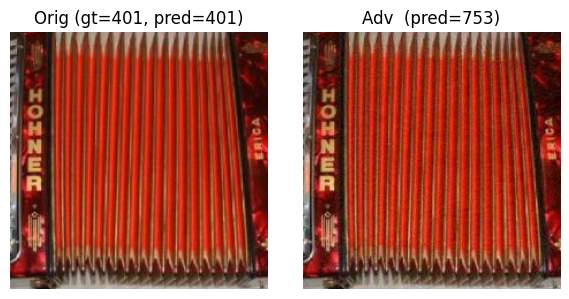

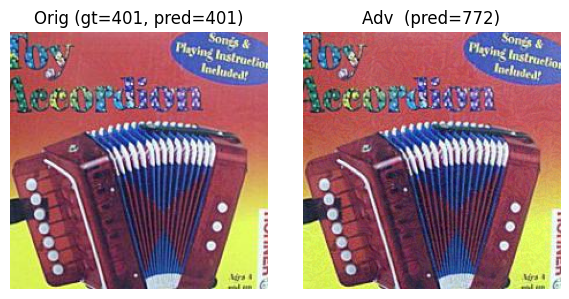

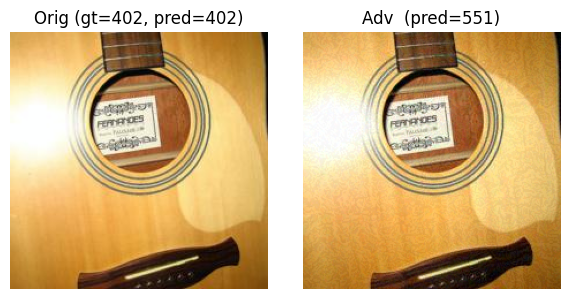

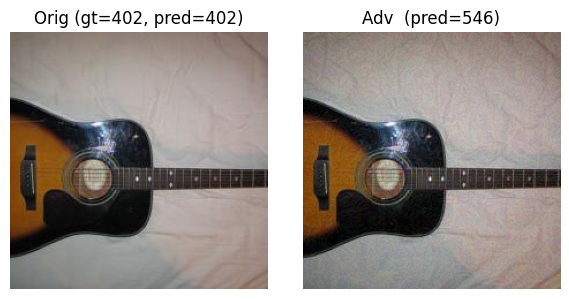

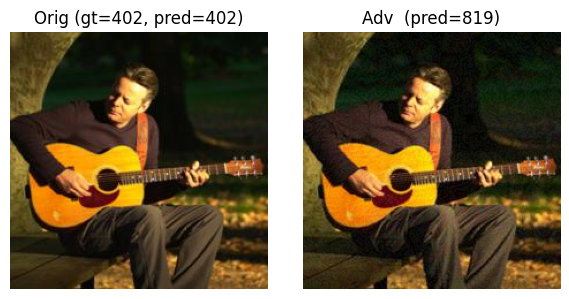

In [11]:
import matplotlib.pyplot as plt

for idx, (o, a, gt, pc, pa) in enumerate(miscls, 1):
    o_np = o.numpy().transpose(1,2,0) * np.array(STD) + np.array(MEAN)
    a_np = a.numpy().transpose(1,2,0) * np.array(STD) + np.array(MEAN)
    o_np = np.clip(o_np, 0, 1)
    a_np = np.clip(a_np, 0, 1)

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6,3))
    ax1.imshow(o_np)
    ax1.set_title(f"Orig (gt={gt}, pred={pc})")
    ax1.axis('off')

    ax2.imshow(a_np)
    ax2.set_title(f"Adv  (pred={pa})")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

## TASK - 3: Improved attacks

In [12]:
epsilon   = 0.02
num_steps = 10
alpha_raw = epsilon / num_steps   # step size in raw pixel units
ADV2_DIR  = "/content/Adversarial_TestSet2"
os.makedirs(ADV2_DIR, exist_ok=True)

# Precompute normalization tensors & bounds
mean_t   = torch.tensor(MEAN, device=device).view(1,3,1,1)
std_t    = torch.tensor(STD,  device=device).view(1,3,1,1)
eps_norm = (epsilon  / std_t).to(device)
alpha_norm = (alpha_raw / std_t).to(device)
lower    = (0.0 - mean_t) / std_t
upper    = (1.0 - mean_t) / std_t

# Prepare trackers
adv2_total = adv2_top1 = adv2_top5 = 0
max_pert_raw2  = 0.0
max_pert_norm2  = 0.0
miscls2    = []   # store up to 5 (orig, adv, gt, orig_pred, adv_pred)

# original file paths to replicate folder structure
paths2 = [p for p, _ in ds.samples]
ptr2   = 0

In [13]:
import time

# Start timing the entire attack loop
start = time.perf_counter()

for imgs, labels in loader:
    imgs, labels = imgs.to(device), labels.to(device)
    orig = imgs.clone().detach()

    # 1) Compute clean predictions and pick least‐likely targets
    with torch.no_grad():
        logits_clean = model(orig)
        _, top_preds  = logits_clean.topk(1, dim=1)
        _, all_preds  = logits_clean.topk(logits_clean.size(1), largest=False)
        target_labels = all_preds[:, 0]  # least likely class

    correct_mask = (top_preds[:,0] == labels)

    # 2) Iterative targeted PGD
    x_adv = orig.clone().detach()
    for _ in range(num_steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        loss   = F.cross_entropy(logits, target_labels)
        model.zero_grad(); loss.backward()

        # move toward target, then project into the L∞ ball and clamp
        x_adv = x_adv - alpha_norm * x_adv.grad.sign()
        x_adv = torch.max(torch.min(x_adv, orig + eps_norm),
                          orig - eps_norm)
        x_adv = torch.max(torch.min(x_adv, upper), lower).detach()

    # 3) Evaluate adversarial examples
    with torch.no_grad():
        logits_adv   = model(x_adv)
        _, preds5    = logits_adv.topk(5, dim=1)
        adv2_top1   += (preds5[:,0] == labels).sum().item()
        adv2_top5   += preds5.eq(labels.unsqueeze(1)).any(dim=1).sum().item()
        adv2_total  += labels.size(0)

    # 4) Track perturbations, save images, collect failures
    for i in range(imgs.size(0)):
        o, a = orig[i], x_adv[i]
        diff = (a - o).abs()

        # record normalized/raw L∞
        max_pert_norm2 = max(max_pert_norm2, diff.max().item())
        max_pert_raw2  = max(max_pert_raw2, (diff * std_t).max().item())

        # denormalize and save
        a_unn  = torch.clamp(a * std_t + mean_t, 0, 1)
        rel    = os.path.relpath(paths2[ptr2], EXTRACT_PATH)
        out_p  = os.path.join(ADV2_DIR, rel)
        os.makedirs(os.path.dirname(out_p), exist_ok=True)
        torchvision.utils.save_image(a_unn, out_p)

        # log a few examples that flip from correct to incorrect
        if correct_mask[i] and preds5[i,0] != labels[i] and len(miscls2) < 5:
            miscls2.append((
                o.cpu(), a.cpu(),
                labels[i].item(),
                top_preds[i,0].item(),
                preds5[i,0].item()
            ))
        ptr2 += 1

# Print total elapsed time
elapsed = time.perf_counter() - start
print(f"Attack loop took {elapsed:.2f} seconds")


Attack loop took 27.43 seconds


In [14]:
adv2_acc1 = 100 * adv2_top1 / adv2_total
adv2_acc5 = 100 * adv2_top5 / adv2_total
drop1_2 = (100 * top1 / total - adv2_acc1)
drop5_2 = (100 * top5 / total - adv2_acc5)

print(f"\nAdversarial Test Set saved to: {ADV2_DIR}")
print(f"Max L_inf perturbation observed: {max_pert_norm2:.4f}")
print(f"Max L_inf perturbation observed (raw pixels): {max_pert_raw2:.4f}")
print(f"Adversarial Top‑1: {adv2_acc1:6.2f}%")
print(f"Adversarial Top‑5: {adv2_acc5:6.2f}%")
print(f"Top‑1 accuracy drop: {'Decrease' if drop1_2 > 0 else 'Increase'}{abs(drop1_2):6.2f}%")
print(f"Top‑5 accuracy drop: {'Decrease' if drop5_2 > 0 else 'Increase'}{abs(drop5_2):6.2f}%")


Adversarial Test Set saved to: /content/Adversarial_TestSet2
Max L_inf perturbation observed: 0.0893
Max L_inf perturbation observed (raw pixels): 0.0200
Adversarial Top‑1:   0.20%
Adversarial Top‑5:   2.00%
Top‑1 accuracy drop: Decrease 75.80%
Top‑5 accuracy drop: Decrease 92.20%


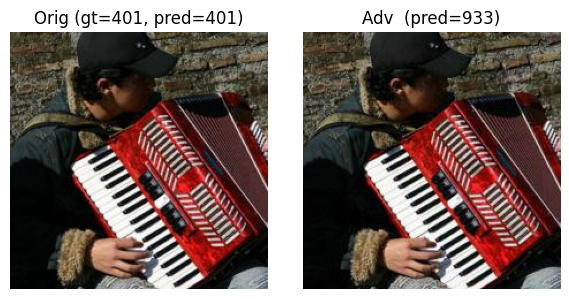

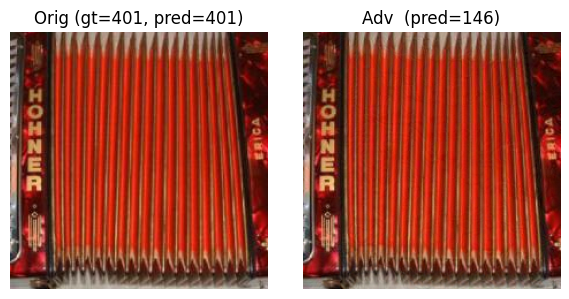

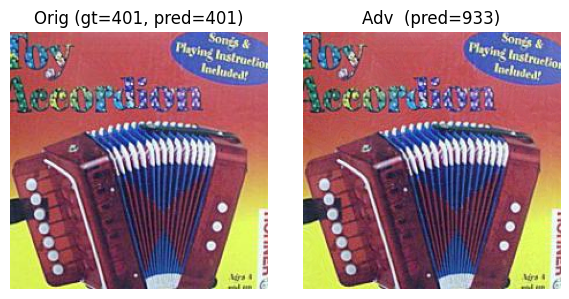

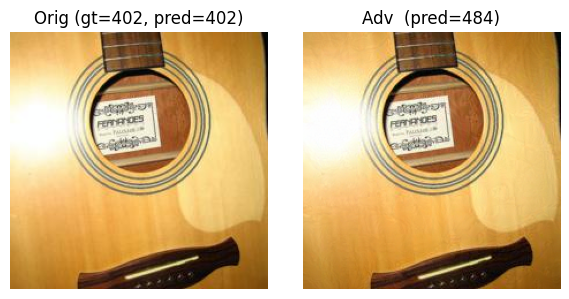

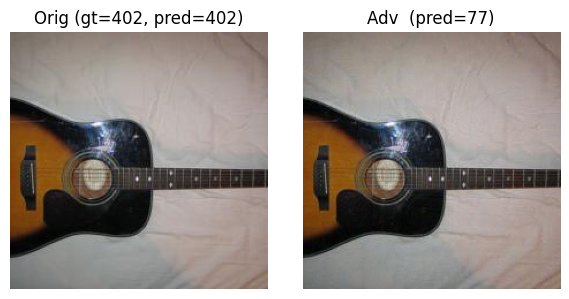

In [15]:
import matplotlib.pyplot as plt

for idx, (o, a, gt, pc, pa) in enumerate(miscls2, 1):
    o_np = o.numpy().transpose(1,2,0) * np.array(STD) + np.array(MEAN)
    a_np = a.numpy().transpose(1,2,0) * np.array(STD) + np.array(MEAN)
    o_np = np.clip(o_np, 0, 1)
    a_np = np.clip(a_np, 0, 1)

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6,3))
    ax1.imshow(o_np)
    ax1.set_title(f"Orig (gt={gt}, pred={pc})")
    ax1.axis('off')

    ax2.imshow(a_np)
    ax2.set_title(f"Adv  (pred={pa})")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

## TASK - 4 : Patch attacks

In [16]:
import random

In [17]:
epsilon    = 0.5
patch_size = 32
num_steps  = 10
alpha_raw  = epsilon / num_steps
ADV3_DIR   = "/content/Adversarial_TestSet3"
os.makedirs(ADV3_DIR, exist_ok=True)

# normalization tensors
mean_t     = torch.tensor(MEAN, device=device).view(1,3,1,1)
std_t      = torch.tensor(STD,  device=device).view(1,3,1,1)
eps_norm   = (epsilon  / std_t).to(device)        # (1,3,1,1)
alpha_norm = (alpha_raw / std_t).to(device)      # (1,3,1,1)
lower      = (0.0 - mean_t) / std_t
upper      = (1.0 - mean_t) / std_t

adv3_total = adv3_top1 = adv3_top5 = 0
max_pert_raw3  = 0.0
max_pert_norm3  = 0.0
miscls3    = []
paths3     = [p for p,_ in ds.samples]
ptr3       = 0

In [18]:
import time
start = time.perf_counter()
for imgs, labels in loader:
    imgs, labels = imgs.to(device), labels.to(device)
    orig = imgs.clone().detach()
    batch_size = imgs.size(0)

    # compute clean preds & least‑likely targets
    with torch.no_grad():
        logits_clean = model(orig)
        _, preds_clean = logits_clean.topk(1, dim=1)
        _, all_preds   = logits_clean.topk(logits_clean.size(1), dim=1, largest=False)
        target_labels = all_preds[:,0]

    correct_mask = (preds_clean[:,0] == labels)
    adv_imgs = orig.clone().detach()

    # targeted PGD on random 32×32 patch
    for i in range(batch_size):
        x = orig[i:i+1].clone().detach()
        tgt = target_labels[i:i+1]
        _, _, H, W = x.shape

        # choose random top‑left for the patch
        h0 = random.randint(0, H - patch_size)
        w0 = random.randint(0, W - patch_size)

        for _ in range(num_steps):
            x.requires_grad_(True)
            out = model(x)
            loss = F.cross_entropy(out, tgt)
            model.zero_grad(); loss.backward()
            grad_sign = x.grad.sign()

            # extract patch, step toward target, project & clamp
            x_patch = x[:, :, h0:h0+patch_size, w0:w0+patch_size]
            g_patch = grad_sign[:, :, h0:h0+patch_size, w0:w0+patch_size]

            x_patch = x_patch - alpha_norm * g_patch
            # project with broadcasting: eps_norm is (1,3,1,1)
            orig_patch = orig[i:i+1, :, h0:h0+patch_size, w0:w0+patch_size]
            x_patch = torch.max(
                torch.min(x_patch, orig_patch + eps_norm),
                orig_patch - eps_norm
            )

            # place patch back, then clamp the full image
            x = x.clone().detach()
            x[:, :, h0:h0+patch_size, w0:w0+patch_size] = x_patch
            x = torch.max(torch.min(x, upper), lower).detach()

        adv_imgs[i:i+1] = x

    # evaluate
    with torch.no_grad():
        out_adv = model(adv_imgs)
        _, p5   = out_adv.topk(5, dim=1)
        adv3_top1 += (p5[:,0] == labels).sum().item()
        adv3_top5 += p5.eq(labels.unsqueeze(1)).any(dim=1).sum().item()
        adv3_total += batch_size

    # save & record
    for i in range(batch_size):
        o = orig[i:i+1]; a = adv_imgs[i:i+1]
        # track max L_inf perturbation
        diff3 = (a - o).abs()

        # normalized‐domain L_inf
        pert_norm3 = diff3.max().item()
        max_pert_norm3 = max(max_pert_norm3, pert_norm3)

        # raw‐pixel L_inf: scale by std before taking max
        pert_raw3 = (diff3 * std_t).max().item()
        max_pert_raw3 = max(max_pert_raw3, pert_raw3)

        # denormalize & save
        a_unn = a * std_t + mean_t
        a_unn = torch.clamp(a_unn, 0, 1)
        rel   = os.path.relpath(paths3[ptr3], EXTRACT_PATH)
        outp  = os.path.join(ADV3_DIR, rel)
        os.makedirs(os.path.dirname(outp), exist_ok=True)
        torchvision.utils.save_image(a_unn, outp)

        if correct_mask[i] and p5[i,0] != labels[i] and len(miscls3) < 5:
            miscls3.append((
                o.cpu(), a.cpu(),
                labels[i].item(),
                preds_clean[i,0].item(),
                p5[i,0].item()
            ))
        ptr3 += 1

elapsed = time.perf_counter() - start
print(f"Attack loop took {elapsed:.2f} seconds")

Attack loop took 72.66 seconds


In [19]:
adv3_acc1 = 100 * adv3_top1 / adv3_total
adv3_acc5 = 100 * adv3_top5 / adv3_total
drop1_3   = (100 * top1/total) - adv3_acc1
drop5_3   = (100 * top5/total) - adv3_acc5

print(f"\nAdversarial Test Set saved to: {ADV3_DIR}")
print(f"Max L_inf perturbation observed: {max_pert_norm3:.4f}")
print(f"Max L_inf perturbation observed (raw pixels): {max_pert_raw3:.4f}")
print(f"Adversarial Top‑1: {adv3_acc1:6.2f}%")
print(f"Adversarial Top‑5: {adv3_acc5:6.2f}%")
print(f"Top‑1 accuracy drop: {'Decrease' if drop1_3>0 else 'Increase'}{abs(drop1_3):6.2f}%")
print(f"Top‑5 accuracy drop: {'Decrease' if drop5_3>0 else 'Increase'}{abs(drop5_3):6.2f}%")



Adversarial Test Set saved to: /content/Adversarial_TestSet3
Max L_inf perturbation observed: 2.2321
Max L_inf perturbation observed (raw pixels): 0.5000
Adversarial Top‑1:  63.40%
Adversarial Top‑5:  86.20%
Top‑1 accuracy drop: Decrease 12.60%
Top‑5 accuracy drop: Decrease  8.00%


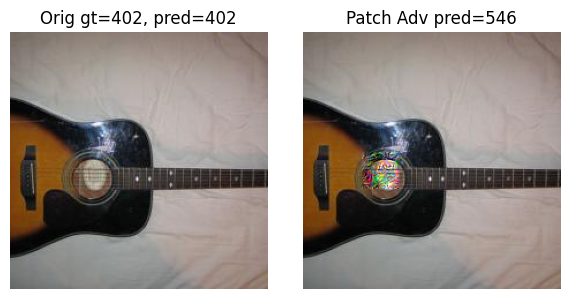

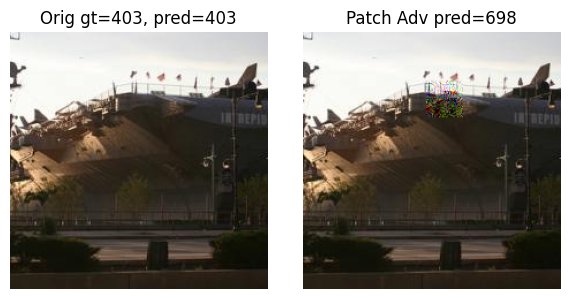

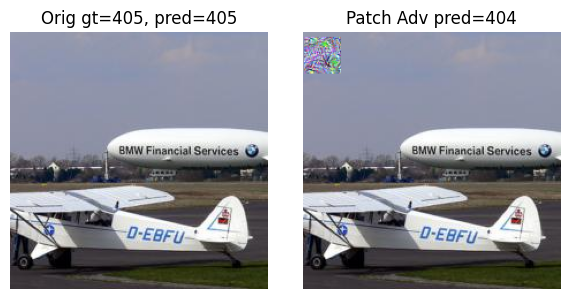

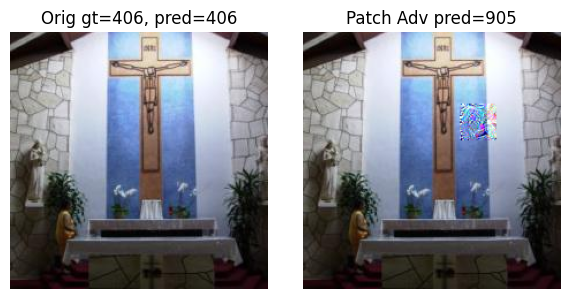

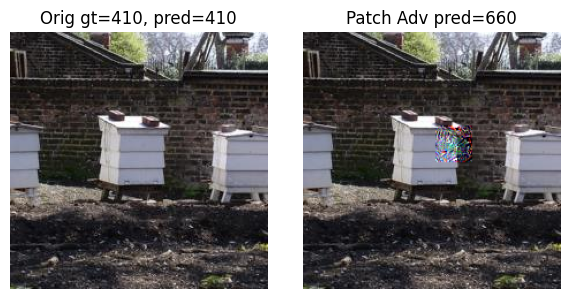

In [20]:
import matplotlib.pyplot as plt

for o, a, gt, pc, pa in miscls3:
    # o, a have shape (1,3,H,W) → squeeze to (3,H,W)
    o_img = o.squeeze(0)
    a_img = a.squeeze(0)

    # permute to (H,W,3) and unnormalize
    o_np = o_img.permute(1,2,0).numpy() * np.array(STD) + np.array(MEAN)
    a_np = a_img.permute(1,2,0).numpy() * np.array(STD) + np.array(MEAN)

    o_np = np.clip(o_np, 0, 1)
    a_np = np.clip(a_np, 0, 1)

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(6,3))
    ax1.imshow(o_np)
    ax1.set_title(f"Orig gt={gt}, pred={pc}")
    ax1.axis('off')

    ax2.imshow(a_np)
    ax2.set_title(f"Patch Adv pred={pa}")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

## Task - 5 : Transferring Attacks

In [21]:
def make_loader(root_dir):
    ds = datasets.ImageFolder(
        root=root_dir,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ]),
        target_transform=lambda idx: global_ids[idx]
    )
    return DataLoader(ds,
                      batch_size=BATCH_SIZE,
                      shuffle=False,
                      num_workers=NUM_WORKERS,
                      pin_memory=PIN_MEMORY)

# reuse the original loader for the clean set
loaders = {
    "Original": loader,
    "Adv Set 1": make_loader(ADV1_DIR),
    "Adv Set 2": make_loader(ADV2_DIR),
    "Adv Set 3": make_loader(ADV3_DIR),
}

# Instantiate three diverse pretrained models
models_to_eval = {
    "DenseNet‑121":   models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1),
    "VisionTransformer‑B/16": models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1),
    "MobileNetV3‑Large":      models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1),
}

results = {}

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 181MB/s]
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 175MB/s]
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 118MB/s] 


In [22]:
for name, mdl in models_to_eval.items():
    mdl = mdl.to(device).eval()  # move model to device and set evaluation mode
    metrics = {}
    for ds_name, ds_loader in loaders.items():
        total = top1 = top5 = 0
        with torch.no_grad():  # no gradients needed for inference
            for imgs, labels in ds_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = mdl(imgs)                    # forward pass
                _, p5 = out.topk(5, dim=1)         # top-5 predictions
                top1 += (p5[:,0] == labels).sum().item()               # count top-1 correct
                top5 += p5.eq(labels.unsqueeze(1)).any(dim=1).sum().item()  # count top-5 correct
                total += labels.size(0)
        # store Top-1 and Top-5 accuracy in percent
        metrics[ds_name] = (100 * top1 / total, 100 * top5 / total)
    results[name] = metrics      # save metrics for this model

In [23]:
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    for ds_name, (acc1, acc5) in metrics.items():
        print(f"{ds_name:12s} => Top‑1: {acc1:6.2f}%   Top‑5: {acc5:6.2f}%")


DenseNet‑121
Original     => Top‑1:  74.80%   Top‑5:  93.60%
Adv Set 1    => Top‑1:  51.40%   Top‑5:  79.00%
Adv Set 2    => Top‑1:  72.20%   Top‑5:  93.20%
Adv Set 3    => Top‑1:  71.80%   Top‑5:  93.20%

VisionTransformer‑B/16
Original     => Top‑1:  91.60%   Top‑5:  99.60%
Adv Set 1    => Top‑1:  84.40%   Top‑5:  97.60%
Adv Set 2    => Top‑1:  91.20%   Top‑5:  99.20%
Adv Set 3    => Top‑1:  90.20%   Top‑5:  99.20%

MobileNetV3‑Large
Original     => Top‑1:  83.80%   Top‑5:  97.00%
Adv Set 1    => Top‑1:  63.40%   Top‑5:  87.80%
Adv Set 2    => Top‑1:  82.60%   Top‑5:  96.00%
Adv Set 3    => Top‑1:  81.00%   Top‑5:  95.80%
